# 랜덤포레스트

## 학습 목표

**앙상블 학습의 개념 이해** 집단 지성 원리와 배깅/부스팅의 차이를 설명함

**랜덤포레스트 원리 파악** 두 가지 랜덤(데이터, 특성)과 투표 메커니즘을 이해함

**수학적 배경 습득** 배깅 예측 공식과 OOB 오차 계산을 수식으로 표현함

**실습 능력 배양** RandomForestClassifier로 안정적인 분류 모델을 구축함

# 1. 앙상블 학습의 이론적 배경

## 1.1 앙상블(Ensemble) 학습이란?

### 정의

앙상블 학습은 **여러 개의 기본 모델(base learner)** 을 결합하여 단일 모델보다 **더 정확하고 안정적인 예측**을 수행하는 기계학습 기법임.

### 일상적 비유

| 상황 | 단일 모델 | 앙상블 모델 |
|------|----------|------------|
| 의료 진단 | 한 명의 의사 소견 | **여러 전문의의 협진** |
| 투자 결정 | 한 명의 분석가 의견 | **다수 분석가의 종합 의견** |
| 시험 평가 | 한 번의 시험 결과 | **여러 번 시험의 평균** |
| 제품 검사 | 한 명의 검사원 | **다수 검사원의 교차 검증** |

### 집단 지성(Wisdom of Crowds)의 수학적 원리

#### Francis Galton의 황소 무게 맞추기 실험 (1906년)

영국 플리머스에서 열린 가축 박람회에서 약 800명의 참가자가 황소의 무게를 추측하는 대회가 열렸음. 개별 추측값은 큰 오차를 보였지만, **전체 참가자의 중앙값(1,207파운드)** 은 실제 무게(1,198파운드)와 **0.8%** 오차에 불과했음.

#### 수학적 설명: 오차 상쇄의 원리

각 모델 $f_i(x)$의 예측을 다음과 같이 분해할 수 있음:

$$f_i(x) = y_{true} + \epsilon_i$$

여기서:
- $y_{true}$: 실제 값
- $\epsilon_i$: i번째 모델의 오차

**B개 모델의 평균 예측**:

$$\bar{f}(x) = \frac{1}{B}\sum_{i=1}^{B}f_i(x) = y_{true} + \frac{1}{B}\sum_{i=1}^{B}\epsilon_i$$

**핵심 가정**: 각 모델의 오차 $\epsilon_i$가 서로 **독립적**이고 **기댓값이 0**이면:

$$E\left[\frac{1}{B}\sum_{i=1}^{B}\epsilon_i\right] = \frac{1}{B}\sum_{i=1}^{B}E[\epsilon_i] = 0$$

**분산의 감소**:

$$Var\left(\frac{1}{B}\sum_{i=1}^{B}\epsilon_i\right) = \frac{1}{B^2}\sum_{i=1}^{B}Var(\epsilon_i) = \frac{\sigma^2}{B}$$

결론: 모델 수 B가 증가하면 **분산이 $\frac{1}{B}$로 감소**함.

### 좋은 앙상블의 두 가지 조건

| 조건 | 수학적 표현 | 의미 |
|------|------------|------|
| **정확성(Accuracy)** | $E[\epsilon_i] \approx 0$ | 각 모델이 랜덤 추측보다 나아야 함 |
| **다양성(Diversity)** | $Cov(\epsilon_i, \epsilon_j) \approx 0$ | 모델들이 서로 다른 오류를 내야 함 |

**상관관계가 있는 경우의 분산**:

$$Var\left(\frac{1}{B}\sum_{i=1}^{B}f_i\right) = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$$

여기서:
- $\rho$: 모델 간 평균 상관계수 $(0 \leq \rho \leq 1)$
- $\sigma^2$: 개별 모델의 분산

**해석**:
- $\rho = 0$ (완전 독립): $Var = \frac{\sigma^2}{B}$ (최대 분산 감소)
- $\rho = 1$ (완전 상관): $Var = \sigma^2$ (분산 감소 없음)

따라서 앙상블 효과를 극대화하려면 **모델 간 상관관계를 최소화**해야 함.

## 1.2 앙상블 방법의 분류

```mermaid
flowchart TD
    A[앙상블 방법] --> B[배깅 Bagging]
    A --> C[부스팅 Boosting]
    A --> D[스태킹 Stacking]

    B --> B1["병렬 학습<br/>(독립적)"]
    B --> B2[대표: 랜덤포레스트]
    B --> B3[목표: 분산 감소]

    C --> C1["순차 학습<br/>(의존적)"]
    C --> C2[대표: XGBoost, LightGBM]
    C --> C3[목표: 편향 감소]

    D --> D1["계층 학습<br/>(메타 모델)"]
    D --> D2[대표: 스태킹 앙상블]
    D --> D3[목표: 다양한 모델 결합]
```

### 배깅(Bagging) vs 부스팅(Boosting) 상세 비교

| 구분 | 배깅 (Bagging) | 부스팅 (Boosting) |
|------|---------------|------------------|
| **Full Name** | Bootstrap Aggregating | - |
| **학습 방식** | 병렬 (독립) | 순차 (의존) |
| **데이터 샘플링** | 부트스트랩 (복원 추출) | 가중치 조정 |
| **주요 목표** | **분산(Variance) 감소** | **편향(Bias) 감소** |
| **기본 모델** | 복잡한 모델 (깊은 트리) | 단순한 모델 (얕은 트리) |
| **대표 알고리즘** | 랜덤포레스트 | XGBoost, LightGBM, AdaBoost |
| **과대적합 위험** | 낮음 | 주의 필요 |
| **병렬 처리** | 가능 | 제한적 |

## 1.3 배깅(Bagging)의 수학적 원리

### 부트스트랩 샘플링(Bootstrap Sampling)

원본 데이터셋 $D = \{(x_1, y_1), (x_2, y_2), \ldots, (x_n, y_n)\}$에서 **복원 추출**로 새로운 데이터셋을 생성하는 방식임.

### 부트스트랩에서 특정 샘플이 제외될 확률

n개의 데이터에서 n번 복원 추출할 때, 특정 샘플 $x_i$가 **한 번도 선택되지 않을 확률**:

$$P(x_i \text{ 제외}) = \left(1 - \frac{1}{n}\right)^n$$

**극한값 계산**:

$$\lim_{n \to \infty} \left(1 - \frac{1}{n}\right)^n = e^{-1} \approx 0.368$$

**결론**: 데이터 크기와 무관하게 각 부트스트랩 샘플에서 약 **36.8%의 데이터가 제외됨**.

아래 코드는 부트스트랩 샘플링의 제외 확률이 이론값 $e^{-1} \approx 0.368$에 수렴하는지 실험적으로 검증함.

In [1]:
# 필요 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import time
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("라이브러리 로드 완료")

라이브러리 로드 완료


In [2]:
# 부트스트랩 샘플링의 제외 확률 실험
n_values = [10, 50, 100, 500, 1000, 5000]
n_bootstrap = 1000

print("=" * 65)
print("부트스트랩 샘플링: 이론값 vs 실험값 비교")
print("=" * 65)
print(f"{'데이터 크기 n':>12} | {'이론적 제외율':>15} | {'실험적 제외율':>15} | {'오차':>10}")
print("-" * 65)

theoretical_values = []
experimental_values = []

for n in n_values:
    theoretical = (1 - 1/n) ** n
    theoretical_values.append(theoretical)
    
    exclusion_counts = []
    for _ in range(n_bootstrap):
        bootstrap_indices = np.random.choice(n, size=n, replace=True)
        unique_indices = len(np.unique(bootstrap_indices))
        excluded = n - unique_indices
        exclusion_counts.append(excluded / n)
    
    experimental = np.mean(exclusion_counts)
    experimental_values.append(experimental)
    
    error = abs(theoretical - experimental)
    print(f"{n:>12} | {theoretical:>15.6f} | {experimental:>15.6f} | {error:>10.6f}")

print("-" * 65)
print(f"{'e^(-1)':>12} | {np.exp(-1):>15.6f} | {'(극한값)':>15} |")
print("=" * 65)

부트스트랩 샘플링: 이론값 vs 실험값 비교
    데이터 크기 n |         이론적 제외율 |         실험적 제외율 |         오차
-----------------------------------------------------------------
          10 |        0.348678 |        0.351800 |   0.003122
          50 |        0.364170 |        0.364100 |   0.000070
         100 |        0.366032 |        0.366120 |   0.000088
         500 |        0.367511 |        0.367416 |   0.000095
        1000 |        0.367695 |        0.367615 |   0.000080
        5000 |        0.367843 |        0.367929 |   0.000086
-----------------------------------------------------------------
      e^(-1) |        0.367879 |           (극한값) |


**결과 해석**: n이 증가할수록 실험적 제외율이 이론값 $e^{-1} \approx 0.368$에 수렴함을 확인할 수 있음. 이는 부트스트랩 샘플링의 핵심 특성으로, 각 트리 학습에서 약 36.8%의 데이터가 제외되어 OOB(Out-of-Bag) 평가에 활용됨.

### 배깅 예측 공식

#### 분류 문제: 다수결 투표 (Majority Voting)

B개의 기본 분류기를 사용한 앙상블의 최종 예측:

$$\hat{y} = \text{mode}\{f_1(x), f_2(x), \ldots, f_B(x)\}$$

또는 확률적 표현:

$$\hat{y} = \arg\max_c \sum_{b=1}^{B} \mathbb{I}(f_b(x) = c)$$

여기서:
- $\hat{y}$: 최종 예측 클래스
- $f_b(x)$: b번째 트리의 예측
- $B$: 트리 개수 (n_estimators)
- $\mathbb{I}(\cdot)$: 지시 함수 (조건 참이면 1, 거짓이면 0)
- $c$: 가능한 클래스 레이블

#### 회귀 문제: 평균 (Averaging)

$$\hat{y} = \frac{1}{B}\sum_{b=1}^{B}f_b(x)$$

### OOB(Out-of-Bag) 오차 추정

각 부트스트랩 샘플에서 **제외된(OOB) 데이터**를 사용하여 모델 성능을 추정하는 방식임.

#### OOB 예측 과정

샘플 $x_i$에 대한 OOB 예측:

$$\hat{y}_i^{OOB} = \text{mode}\{f_b(x_i) : x_i \notin D_b\}$$

여기서 $D_b$는 b번째 부트스트랩 샘플임.

#### OOB 오차 계산

$$OOB_{error} = \frac{1}{n}\sum_{i=1}^{n}\mathbb{I}(y_i \neq \hat{y}_i^{OOB})$$

**OOB 점수의 장점**:
1. 별도의 검증 세트 없이 성능 추정 가능
2. 데이터가 적을 때 유용
3. 교차 검증과 유사한 효과

In [3]:
# OOB 예측 과정 시뮬레이션
np.random.seed(42)

n_samples = 8
n_trees = 5

# 가상의 실제 레이블
true_labels = np.array([1, 0, 1, 1, 0, 0, 1, 0])

# 각 트리의 부트스트랩 샘플과 예측 생성
print("=" * 80)
print("OOB(Out-of-Bag) 예측 과정 시뮬레이션")
print("=" * 80)

# 트리별 부트스트랩 인덱스
bootstrap_indices = []
for t in range(n_trees):
    indices = np.random.choice(n_samples, size=n_samples, replace=True)
    bootstrap_indices.append(set(indices))

# 트리별 예측 (간단히 생성)
tree_predictions = np.array([
    [1, 0, 1, 1, 0, 1, 1, 0],
    [1, 0, 1, 0, 0, 0, 1, 1],
    [0, 1, 1, 1, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 0, 0, 0],
    [1, 0, 0, 1, 0, 0, 1, 0]
])

# OOB 상태 테이블 출력
print("\n[각 샘플의 OOB 상태 및 예측]")
print("-" * 80)
header = f"{'샘플':>4} | {'실제':>4} | " + " | ".join([f"트리{t+1}" for t in range(n_trees)]) + " | OOB투표 | 결과"
print(header)
print("-" * 80)

oob_predictions = []
oob_correct = 0

for i in range(n_samples):
    row = f"  x{i+1} | {true_labels[i]:>4} | "
    oob_votes = []
    
    for t in range(n_trees):
        if i in bootstrap_indices[t]:
            row += f"  학습  | "
        else:
            pred = tree_predictions[t, i]
            row += f" OOB:{pred} | "
            oob_votes.append(pred)
    
    if len(oob_votes) > 0:
        oob_pred = 1 if sum(oob_votes) > len(oob_votes)/2 else 0
        correct = "O" if oob_pred == true_labels[i] else "X"
        if oob_pred == true_labels[i]:
            oob_correct += 1
        vote_str = f"{sum(oob_votes)}:{len(oob_votes)-sum(oob_votes)}"
        row += f" {vote_str:>6} |   {correct}"
    else:
        row += f" {'N/A':>6} |  N/A"
    
    print(row)

print("-" * 80)
oob_accuracy = oob_correct / n_samples
oob_error = 1 - oob_accuracy
print(f"\nOOB 정확도: {oob_correct}/{n_samples} = {oob_accuracy:.1%}")
print(f"OOB 오차: {oob_error:.1%}")

OOB(Out-of-Bag) 예측 과정 시뮬레이션

[각 샘플의 OOB 상태 및 예측]
--------------------------------------------------------------------------------
  샘플 |   실제 | 트리1 | 트리2 | 트리3 | 트리4 | 트리5 | OOB투표 | 결과
--------------------------------------------------------------------------------
  x1 |    1 |  OOB:1 |  OOB:1 |  OOB:0 |   학습  |   학습  |     2:1 |   O
  x2 |    0 |  OOB:0 |   학습  |   학습  |   학습  |   학습  |     0:1 |   O
  x3 |    1 |   학습  |   학습  |   학습  |  OOB:1 |   학습  |     1:0 |   O
  x4 |    1 |   학습  |  OOB:0 |   학습  |   학습  |   학습  |     0:1 |   X
  x5 |    0 |   학습  |   학습  |   학습  |   학습  |   학습  |     N/A |  N/A
  x6 |    0 |  OOB:1 |  OOB:0 |   학습  |   학습  |   학습  |     1:1 |   O
  x7 |    1 |   학습  |   학습  |  OOB:1 |  OOB:0 |  OOB:1 |     2:1 |   O
  x8 |    0 |   학습  |   학습  |   학습  |   학습  |  OOB:0 |     0:1 |   O
--------------------------------------------------------------------------------

OOB 정확도: 6/8 = 75.0%
OOB 오차: 25.0%


# 2. 랜덤포레스트(Random Forest)의 원리


## 2.1 랜덤포레스트의 두 가지 "랜덤"

```mermaid
flowchart TD
    A[랜덤포레스트의 두 가지 랜덤] --> B["1. 데이터 랜덤<br/>(배깅)"]
    A --> C["2. 특성 랜덤<br/>(특성 부분공간)"]
    
    B --> B1[부트스트랩 샘플링]
    B --> B2[각 트리가 다른 데이터로 학습]
    B --> B3[약 63.2% 데이터 사용]
    
    C --> C1[각 분할에서 일부 특성만 고려]
    C --> C2["분류: sqrt(p)개"]
    C --> C3["회귀: p/3개"]
    
    B1 --> D[트리 간 다양성 확보]
    C1 --> D
    D --> E[상관관계 감소 --> 분산 감소]
```

### 랜덤포레스트 학습 알고리즘

**입력**: 학습 데이터 $D = \{(x_i, y_i)\}_{i=1}^n$, 트리 개수 B, 특성 부분집합 크기 m

**알고리즘**:

```
For b = 1 to B:
    1. D에서 n개를 복원 추출하여 부트스트랩 샘플 D_b 생성
    2. D_b로 의사결정나무 T_b 학습:
       - 각 노드에서 p개 특성 중 m개를 무작위 선택
       - 선택된 m개 중 최적의 특성과 분할점 선택
       - 종료 조건까지 재귀적 분할
    3. T_b 저장

예측: 새 데이터 x에 대해
    - 분류: mode{T_1(x), T_2(x), ..., T_B(x)}
    - 회귀: mean{T_1(x), T_2(x), ..., T_B(x)}
```

### 특성 랜덤 선택의 수학적 배경

전체 p개의 특성 중 m개만 선택하는 것의 효과:

**특성 부분집합 크기 (max_features)**:

| 문제 유형 | 권장값 | 수식 |
|----------|--------|------|
| 분류 | $m = \sqrt{p}$ | `max_features='sqrt'` |
| 회귀 | $m = p/3$ | `max_features='auto'` 또는 `p//3` |

**예시**: 100개의 특성이 있을 때
- 분류: $m = \sqrt{100} = 10$개 특성만 각 분할에서 고려
- 회귀: $m = 100/3 \approx 33$개 특성만 각 분할에서 고려

**효과**:
- 강한 특성이 모든 트리에서 선택되는 것을 방지
- 트리 간 상관관계 $\rho$ 감소
- 앙상블 분산 감소: $Var = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$

## 2.2 의사결정나무 vs 랜덤포레스트 비교

| 구분 | 의사결정나무 | 랜덤포레스트 |
|------|-------------|-------------|
| **모델 수** | 1개 | 다수 (100+) |
| **학습 데이터** | 전체 데이터 | 부트스트랩 샘플 |
| **분할 특성** | 전체 특성 | 랜덤 부분집합 |
| **안정성** | 낮음 (데이터 변화에 민감) | 높음 |
| **과대적합** | 쉬움 | 저항력 강함 |
| **해석성** | 높음 (시각화 가능) | 낮음 |
| **예측 성능** | 보통 | 우수 |

## 2.3 랜덤포레스트의 장단점

### 장점

| 장점 | 설명 |
|------|------|
| **높은 예측 정확도** | 다수 트리의 앙상블로 단일 트리보다 우수 |
| **과대적합 저항** | 부트스트랩 + 특성 랜덤으로 일반화 능력 향상 |
| **특성 중요도 신뢰성** | 안정적인 특성 중요도 추정 |
| **튜닝 용이** | 기본 설정으로도 좋은 성능 |
| **결측치 처리** | 결측치에 상대적으로 강건 |
| **병렬 처리** | 트리 학습이 독립적이므로 병렬화 가능 |

### 단점

| 단점 | 설명 |
|------|------|
| **해석의 어려움** | 개별 트리 수백 개를 해석하기 어려움 |
| **메모리 사용량** | 많은 트리 저장으로 메모리 소비 큼 |
| **예측 속도** | 실시간 예측에서 단일 모델보다 느림 |
| **외삽(Extrapolation)** | 학습 데이터 범위 밖 예측에 취약 |

# 3. 실습 - UCI 유압 시스템 상태 분류

## 3.1 실습 데이터셋 소개

### UCI Condition Monitoring of Hydraulic Systems

**UCI Machine Learning Repository**에서 제공하는 **유압 시스템 상태 모니터링 데이터셋**을 활용함.

| 항목 | 내용 |
|------|------|
| **데이터 출처** | UCI Machine Learning Repository (ID: 447) |
| **수집 기관** | Saarland University, Germany |
| **샘플 수** | 2,205 사이클 |
| **센서 수** | 17개 (압력, 유량, 온도, 진동 등) |
| **타겟** | 4가지 고장 유형 (쿨러, 밸브, 펌프, 축압기) |

### 타겟 변수 (밸브 상태)

| 값 | 의미 |
|------|------|
| 100 | 정상 (최적 스위칭) |
| 90 | 약간 지연 |
| 80 | 심각한 지연 |
| 73 | 고장 임박 |

## 3.2 데이터 다운로드 및 로드

UCI Repository에서 직접 데이터를 다운로드하여 로드함. 각 센서 파일에서 통계 특성을 추출하여 사용함.

In [4]:
import os
import urllib.request
import zipfile

def download_hydraulic_data(data_dir='hydraulic_data'):
    """
    UCI Repository에서 유압 시스템 데이터를 다운로드하고 로드하는 함수
    """
    # 다운로드 URL
    url = "https://archive.ics.uci.edu/static/public/447/condition+monitoring+of+hydraulic+systems.zip"
    zip_path = "hydraulic_systems.zip"
    
    # 데이터 디렉토리가 없으면 다운로드
    if not os.path.exists(data_dir):
        print("UCI Repository에서 데이터 다운로드 중...")
        print(f"URL: {url}")
        
        try:
            urllib.request.urlretrieve(url, zip_path)
            print("다운로드 완료. 압축 해제 중...")
            
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall(data_dir)
            
            os.remove(zip_path)
            print("압축 해제 완료!")
            
        except Exception as e:
            print(f"다운로드 실패: {e}")
            print("수동 다운로드가 필요합니다.")
            print(f"다운로드 URL: {url}")
            return None, None
    else:
        print(f"기존 데이터 사용: {data_dir}")
    
    return data_dir

# 데이터 다운로드
data_dir = download_hydraulic_data()

기존 데이터 사용: hydraulic_data


In [5]:
def load_hydraulic_features(data_dir):
    """
    유압 시스템 센서 데이터를 로드하고 통계 특성을 추출하는 함수
    각 센서의 시계열 데이터에서 평균, 표준편차, 최대값, 최소값을 계산함
    """
    print("\n센서 데이터 로드 및 특성 추출 중...")
    
    # 센서 파일 목록
    sensor_files = {
        'PS1': 'PS1.txt', 'PS2': 'PS2.txt', 'PS3': 'PS3.txt',
        'PS4': 'PS4.txt', 'PS5': 'PS5.txt', 'PS6': 'PS6.txt',
        'EPS1': 'EPS1.txt',
        'FS1': 'FS1.txt', 'FS2': 'FS2.txt',
        'TS1': 'TS1.txt', 'TS2': 'TS2.txt', 'TS3': 'TS3.txt', 'TS4': 'TS4.txt',
        'VS1': 'VS1.txt',
        'CE': 'CE.txt', 'CP': 'CP.txt', 'SE': 'SE.txt'
    }
    
    features_dict = {}
    
    for sensor_name, filename in sensor_files.items():
        filepath = os.path.join(data_dir, filename)
        if os.path.exists(filepath):
            # 센서 데이터 로드 (탭 구분)
            data = np.loadtxt(filepath, delimiter='\t')
            
            # 통계 특성 추출
            features_dict[f'{sensor_name}_mean'] = np.mean(data, axis=1)
            features_dict[f'{sensor_name}_std'] = np.std(data, axis=1)
            features_dict[f'{sensor_name}_max'] = np.max(data, axis=1)
            features_dict[f'{sensor_name}_min'] = np.min(data, axis=1)
            
            print(f"  {sensor_name}: {data.shape} -> 4개 특성 추출")
    
    # DataFrame 생성
    X = pd.DataFrame(features_dict)
    
    # 타겟 로드 (profile.txt)
    profile_path = os.path.join(data_dir, 'profile.txt')
    targets = np.loadtxt(profile_path, delimiter='\t')
    
    # 타겟 DataFrame
    y_df = pd.DataFrame(targets, columns=[
        'cooler_condition', 'valve_condition', 'pump_leakage',
        'accumulator_pressure', 'stable_flag'
    ])
    
    print(f"\n특성 추출 완료!")
    print(f"  총 샘플 수: {X.shape[0]}개")
    print(f"  추출된 특성 수: {X.shape[1]}개")
    
    return X, y_df

# 데이터 로드
X, y_df = load_hydraulic_features(data_dir)


센서 데이터 로드 및 특성 추출 중...
  PS1: (2205, 6000) -> 4개 특성 추출
  PS2: (2205, 6000) -> 4개 특성 추출
  PS3: (2205, 6000) -> 4개 특성 추출
  PS4: (2205, 6000) -> 4개 특성 추출
  PS5: (2205, 6000) -> 4개 특성 추출
  PS6: (2205, 6000) -> 4개 특성 추출
  EPS1: (2205, 6000) -> 4개 특성 추출
  FS1: (2205, 600) -> 4개 특성 추출
  FS2: (2205, 600) -> 4개 특성 추출
  TS1: (2205, 60) -> 4개 특성 추출
  TS2: (2205, 60) -> 4개 특성 추출
  TS3: (2205, 60) -> 4개 특성 추출
  TS4: (2205, 60) -> 4개 특성 추출
  VS1: (2205, 60) -> 4개 특성 추출
  CE: (2205, 60) -> 4개 특성 추출
  CP: (2205, 60) -> 4개 특성 추출
  SE: (2205, 60) -> 4개 특성 추출

특성 추출 완료!
  총 샘플 수: 2205개
  추출된 특성 수: 68개


**결과 해석**: 17개 센서 x 4개 통계량 = 68개 특성이 추출됨. 이렇게 시계열 데이터에서 통계적 요약 특성을 추출하면 모델 학습이 효율적이면서도 센서 신호의 주요 특성을 보존할 수 있음.

In [6]:
# 밸브 상태를 타겟으로 선택
y = y_df['valve_condition'].astype(int).values

# 클래스 분포 확인
valve_labels = {
    73: '고장임박 (73%)',
    80: '심각지연 (80%)',
    90: '약간지연 (90%)',
    100: '정상 (100%)'
}

print("=" * 50)
print("밸브 상태 분포")
print("=" * 50)

unique, counts = np.unique(y, return_counts=True)
for val, count in zip(unique, counts):
    label = valve_labels.get(val, str(val))
    print(f"  {label}: {count}개 ({count/len(y):.1%})")

밸브 상태 분포
  고장임박 (73%): 360개 (16.3%)
  심각지연 (80%): 360개 (16.3%)
  약간지연 (90%): 360개 (16.3%)
  정상 (100%): 1125개 (51.0%)


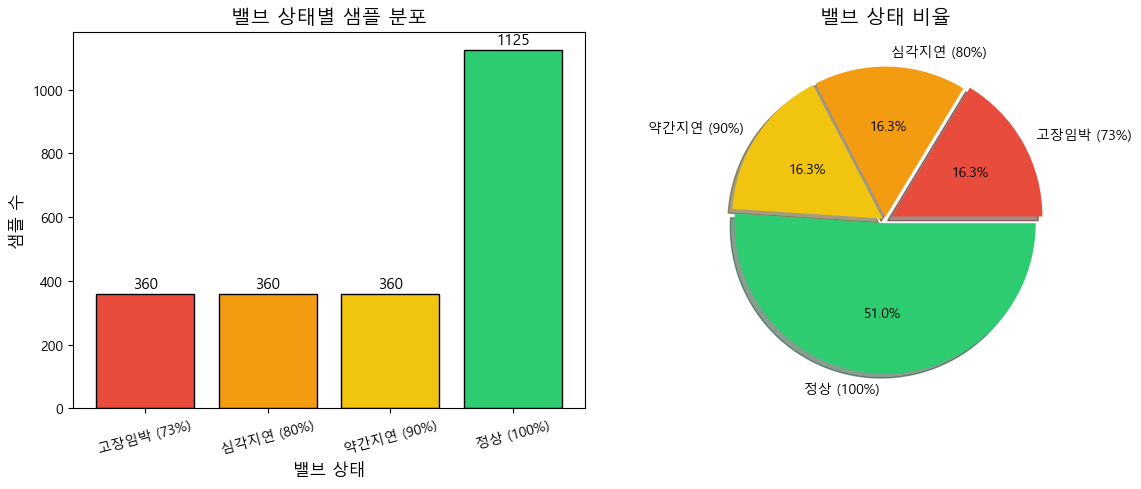

In [7]:
# 타겟 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#e74c3c', '#f39c12', '#f1c40f', '#2ecc71']
labels = [valve_labels[v] for v in sorted(unique)]
counts_sorted = [counts[list(unique).index(v)] for v in sorted(unique)]

# 막대 그래프
ax1 = axes[0]
bars = ax1.bar(labels, counts_sorted, color=colors, edgecolor='black')
ax1.set_xlabel('밸브 상태', fontsize=12)
ax1.set_ylabel('샘플 수', fontsize=12)
ax1.set_title('밸브 상태별 샘플 분포', fontsize=14)
for bar, count in zip(bars, counts_sorted):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{count}', ha='center', va='bottom', fontsize=11)
ax1.tick_params(axis='x', rotation=15)

# 파이 차트
ax2 = axes[1]
ax2.pie(counts_sorted, labels=labels, autopct='%1.1f%%',
        colors=colors, explode=[0.05, 0.02, 0.02, 0.02], shadow=True)
ax2.set_title('밸브 상태 비율', fontsize=14)

plt.tight_layout()
plt.show()

## 3.3 데이터 분할 및 전처리

In [8]:
# 결측치 확인 및 처리
print("[결측치 현황]")
missing = X.isnull().sum().sum()
print(f"  총 결측치: {missing}개")

if missing > 0:
    X = X.fillna(X.median())
    print("  -> 중앙값으로 대체 완료")

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n[데이터 분할]")
print(f"  학습 데이터: {len(X_train)}개")
print(f"  테스트 데이터: {len(X_test)}개")
print(f"  특성 수: {X.shape[1]}개")

[결측치 현황]
  총 결측치: 0개

[데이터 분할]
  학습 데이터: 1764개
  테스트 데이터: 441개
  특성 수: 68개


## 3.4 의사결정나무 vs 랜덤포레스트 성능 비교

In [9]:
print("=" * 70)
print("의사결정나무 vs 랜덤포레스트 성능 비교")
print("=" * 70)

# 의사결정나무
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
start = time.time()
dt.fit(X_train, y_train)
dt_train_time = time.time() - start

dt_train_score = dt.score(X_train, y_train)
dt_test_score = dt.score(X_test, y_test)

print(f"\n[의사결정나무 (max_depth=10)]")
print(f"  학습 시간: {dt_train_time:.4f}초")
print(f"  학습 정확도: {dt_train_score:.4f} ({dt_train_score:.1%})")
print(f"  테스트 정확도: {dt_test_score:.4f} ({dt_test_score:.1%})")
print(f"  과적합 지표: {dt_train_score - dt_test_score:.4f}")

# 랜덤포레스트
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    oob_score=True
)
start = time.time()
rf.fit(X_train, y_train)
rf_train_time = time.time() - start

rf_train_score = rf.score(X_train, y_train)
rf_test_score = rf.score(X_test, y_test)

print(f"\n[랜덤포레스트 (n_estimators=100, max_depth=10)]")
print(f"  학습 시간: {rf_train_time:.4f}초")
print(f"  학습 정확도: {rf_train_score:.4f} ({rf_train_score:.1%})")
print(f"  테스트 정확도: {rf_test_score:.4f} ({rf_test_score:.1%})")
print(f"  OOB 점수: {rf.oob_score_:.4f} ({rf.oob_score_:.1%})")
print(f"  과적합 지표: {rf_train_score - rf_test_score:.4f}")

print(f"\n[비교 결과]")
print(f"  테스트 정확도 향상: {rf_test_score - dt_test_score:+.4f}")

의사결정나무 vs 랜덤포레스트 성능 비교

[의사결정나무 (max_depth=10)]
  학습 시간: 0.0490초
  학습 정확도: 0.9989 (99.9%)
  테스트 정확도: 0.9297 (93.0%)
  과적합 지표: 0.0692

[랜덤포레스트 (n_estimators=100, max_depth=10)]
  학습 시간: 0.1926초
  학습 정확도: 1.0000 (100.0%)
  테스트 정확도: 0.9819 (98.2%)
  OOB 점수: 0.9824 (98.2%)
  과적합 지표: 0.0181

[비교 결과]
  테스트 정확도 향상: +0.0522


**결과 해석**: 랜덤포레스트가 의사결정나무보다 테스트 정확도가 높고, 과적합 지표(학습-테스트 차이)가 작아 더 안정적인 일반화 성능을 보임. OOB 점수는 테스트 정확도와 유사하여 별도 검증 세트 없이도 성능 추정이 가능함.

In [10]:
# 상세 분류 리포트
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)

target_names = [valve_labels[v] for v in sorted(np.unique(y))]

print("\n[의사결정나무 분류 리포트]")
print(classification_report(y_test, y_pred_dt, target_names=target_names))

print("\n[랜덤포레스트 분류 리포트]")
print(classification_report(y_test, y_pred_rf, target_names=target_names))


[의사결정나무 분류 리포트]
              precision    recall  f1-score   support

  고장임박 (73%)       0.96      0.99      0.97        72
  심각지연 (80%)       0.89      0.94      0.92        72
  약간지연 (90%)       0.85      0.81      0.83        72
   정상 (100%)       0.96      0.95      0.95       225

    accuracy                           0.93       441
   macro avg       0.92      0.92      0.92       441
weighted avg       0.93      0.93      0.93       441


[랜덤포레스트 분류 리포트]
              precision    recall  f1-score   support

  고장임박 (73%)       0.99      1.00      0.99        72
  심각지연 (80%)       0.96      0.96      0.96        72
  약간지연 (90%)       0.95      0.97      0.96        72
   정상 (100%)       1.00      0.99      0.99       225

    accuracy                           0.98       441
   macro avg       0.97      0.98      0.98       441
weighted avg       0.98      0.98      0.98       441



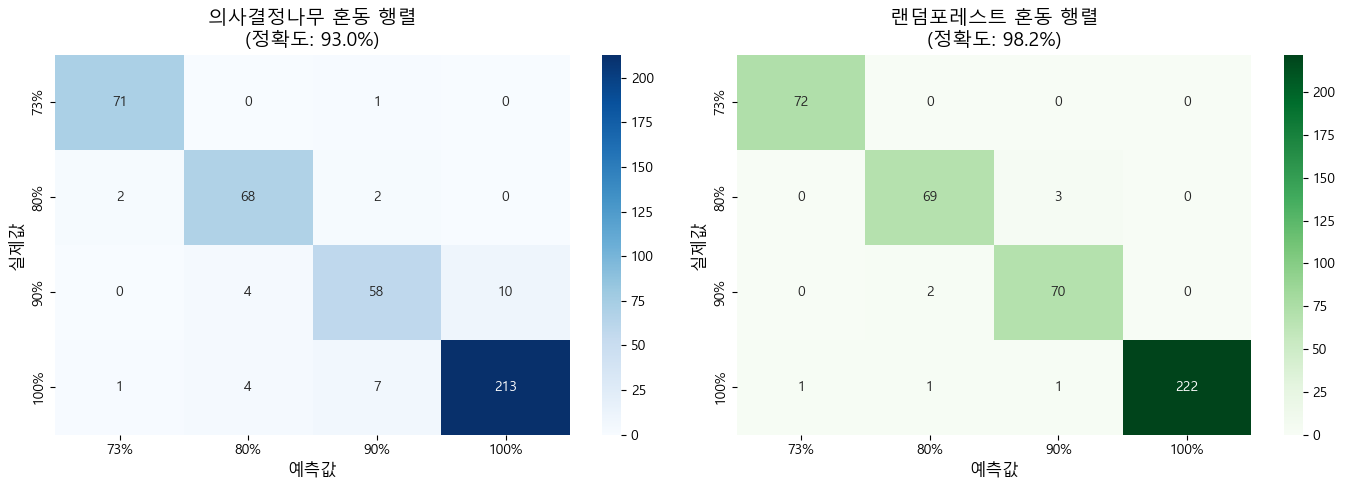

In [11]:
# 혼동 행렬 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 의사결정나무
cm_dt = confusion_matrix(y_test, y_pred_dt)
ax1 = axes[0]
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=ax1,
            xticklabels=[f'{v}%' for v in sorted(np.unique(y))],
            yticklabels=[f'{v}%' for v in sorted(np.unique(y))])
ax1.set_xlabel('예측값', fontsize=12)
ax1.set_ylabel('실제값', fontsize=12)
ax1.set_title(f'의사결정나무 혼동 행렬\n(정확도: {dt_test_score:.1%})', fontsize=14)

# 랜덤포레스트
cm_rf = confusion_matrix(y_test, y_pred_rf)
ax2 = axes[1]
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=ax2,
            xticklabels=[f'{v}%' for v in sorted(np.unique(y))],
            yticklabels=[f'{v}%' for v in sorted(np.unique(y))])
ax2.set_xlabel('예측값', fontsize=12)
ax2.set_ylabel('실제값', fontsize=12)
ax2.set_title(f'랜덤포레스트 혼동 행렬\n(정확도: {rf_test_score:.1%})', fontsize=14)

plt.tight_layout()
plt.show()

## 3.5 n_estimators 최적화

In [12]:
# n_estimators에 따른 성능 변화
n_estimators_range = [10, 25, 50, 75, 100, 150, 200, 300]
train_scores = []
test_scores = []
oob_scores = []
train_times = []

print("=" * 75)
print("n_estimators에 따른 성능 변화")
print("=" * 75)
print(f"{'n_estimators':>12} | {'학습시간':>10} | {'학습정확도':>10} | {'테스트정확도':>12} | {'OOB점수':>10}")
print("-" * 75)

for n_est in n_estimators_range:
    rf_temp = RandomForestClassifier(
        n_estimators=n_est, max_depth=10, random_state=42, n_jobs=-1, oob_score=True
    )
    
    start = time.time()
    rf_temp.fit(X_train, y_train)
    train_time = time.time() - start
    
    train_score = rf_temp.score(X_train, y_train)
    test_score = rf_temp.score(X_test, y_test)
    oob = rf_temp.oob_score_
    
    train_scores.append(train_score)
    test_scores.append(test_score)
    oob_scores.append(oob)
    train_times.append(train_time)
    
    print(f"{n_est:>12} | {train_time:>9.3f}s | {train_score:>10.1%} | {test_score:>12.1%} | {oob:>10.1%}")

best_idx = np.argmax(test_scores)
print("-" * 75)
print(f"최적 n_estimators: {n_estimators_range[best_idx]}, 최고 테스트 정확도: {test_scores[best_idx]:.1%}")

n_estimators에 따른 성능 변화
n_estimators |       학습시간 |      학습정확도 |       테스트정확도 |      OOB점수
---------------------------------------------------------------------------
          10 |     0.038s |      99.9% |        96.1% |      89.6%
          25 |     0.056s |     100.0% |        96.8% |      95.9%
          50 |     0.102s |     100.0% |        98.0% |      97.5%
          75 |     0.135s |     100.0% |        98.4% |      98.2%
         100 |     0.183s |     100.0% |        98.2% |      98.2%
         150 |     0.269s |     100.0% |        98.2% |      98.3%
         200 |     0.343s |     100.0% |        98.2% |      98.5%
         300 |     0.516s |     100.0% |        98.2% |      98.4%
---------------------------------------------------------------------------
최적 n_estimators: 75, 최고 테스트 정확도: 98.4%


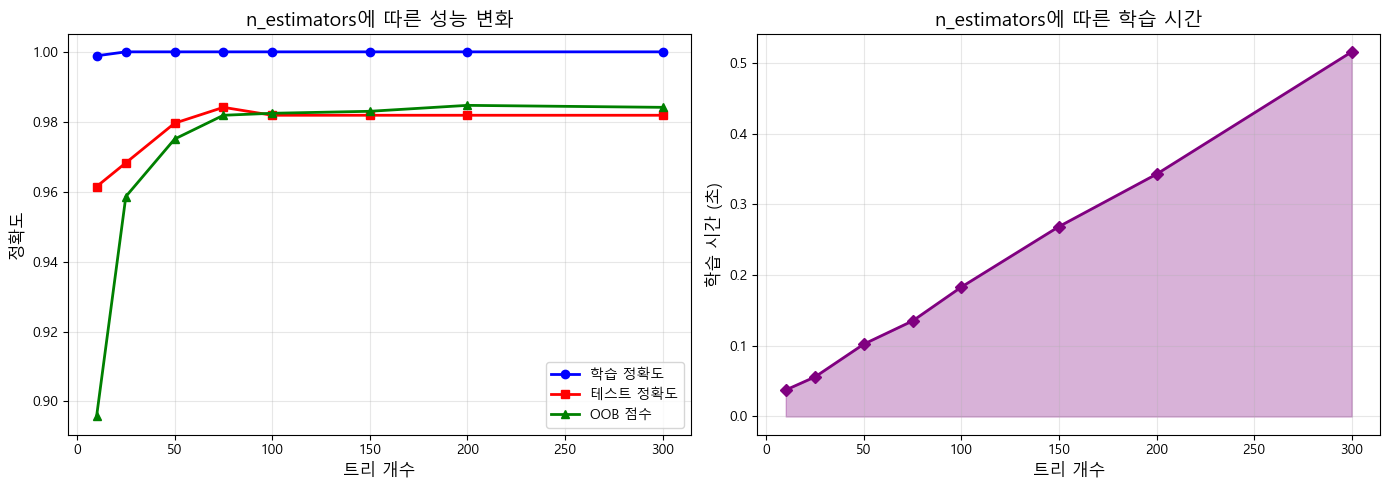

In [13]:
# n_estimators 성능 곡선 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
ax1.plot(n_estimators_range, train_scores, 'b-o', label='학습 정확도', linewidth=2)
ax1.plot(n_estimators_range, test_scores, 'r-s', label='테스트 정확도', linewidth=2)
ax1.plot(n_estimators_range, oob_scores, 'g-^', label='OOB 점수', linewidth=2)
ax1.set_xlabel('트리 개수', fontsize=12)
ax1.set_ylabel('정확도', fontsize=12)
ax1.set_title('n_estimators에 따른 성능 변화', fontsize=14)
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(n_estimators_range, train_times, 'purple', marker='D', linewidth=2)
ax2.fill_between(n_estimators_range, train_times, alpha=0.3, color='purple')
ax2.set_xlabel('트리 개수', fontsize=12)
ax2.set_ylabel('학습 시간 (초)', fontsize=12)
ax2.set_title('n_estimators에 따른 학습 시간', fontsize=14)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3.6 모델 안정성 비교

In [14]:
# 10회 반복 실험으로 안정성 비교
n_experiments = 10
dt_scores_list = []
rf_scores_list = []

print(f"모델 안정성 비교 ({n_experiments}회 반복 실험)...")

for i in range(n_experiments):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=i, stratify=y)
    
    dt_temp = DecisionTreeClassifier(max_depth=10, random_state=i)
    dt_temp.fit(X_tr, y_tr)
    dt_scores_list.append(dt_temp.score(X_te, y_te))
    
    rf_temp = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=i, n_jobs=-1)
    rf_temp.fit(X_tr, y_tr)
    rf_scores_list.append(rf_temp.score(X_te, y_te))

print(f"\n[의사결정나무]")
print(f"  평균: {np.mean(dt_scores_list):.4f}, 표준편차: {np.std(dt_scores_list):.4f}")
print(f"  범위: {min(dt_scores_list):.4f} ~ {max(dt_scores_list):.4f}")

print(f"\n[랜덤포레스트]")
print(f"  평균: {np.mean(rf_scores_list):.4f}, 표준편차: {np.std(rf_scores_list):.4f}")
print(f"  범위: {min(rf_scores_list):.4f} ~ {max(rf_scores_list):.4f}")

if np.std(rf_scores_list) > 0:
    print(f"\n--> 랜덤포레스트가 {np.std(dt_scores_list)/np.std(rf_scores_list):.1f}배 더 안정적")

모델 안정성 비교 (10회 반복 실험)...

[의사결정나무]
  평균: 0.9342, 표준편차: 0.0127
  범위: 0.9138 ~ 0.9615

[랜덤포레스트]
  평균: 0.9789, 표준편차: 0.0072
  범위: 0.9683 ~ 0.9887

--> 랜덤포레스트가 1.7배 더 안정적


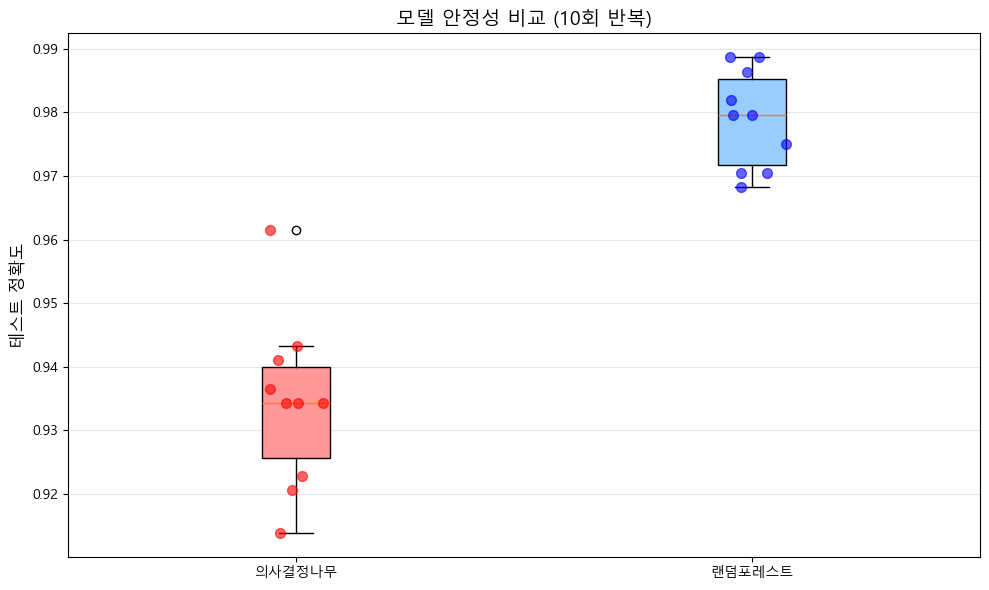

In [15]:
# 안정성 박스플롯
fig, ax = plt.subplots(figsize=(10, 6))

bp = ax.boxplot([dt_scores_list, rf_scores_list], patch_artist=True,
                labels=['의사결정나무', '랜덤포레스트'])

for patch, color in zip(bp['boxes'], ['#FF9999', '#99CCFF']):
    patch.set_facecolor(color)

for i, (scores, color) in enumerate(zip([dt_scores_list, rf_scores_list], ['red', 'blue'])):
    x = np.random.normal(i + 1, 0.04, size=len(scores))
    ax.scatter(x, scores, alpha=0.6, color=color, s=50, zorder=5)

ax.set_ylabel('테스트 정확도', fontsize=12)
ax.set_title(f'모델 안정성 비교 ({n_experiments}회 반복)', fontsize=14)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 3.7 특성 중요도 분석

In [16]:
# 특성 중요도 비교
dt_importances = dt.feature_importances_
rf_importances = rf.feature_importances_

rf_sorted_idx = np.argsort(rf_importances)[::-1]

print("특성 중요도 상위 15개")
print("-" * 60)
print(f"{'순위':>4} | {'특성':>25} | {'의사결정나무':>12} | {'랜덤포레스트':>12}")
print("-" * 60)

for rank, idx in enumerate(rf_sorted_idx[:15], 1):
    print(f"{rank:>4} | {X.columns[idx]:>25} | {dt_importances[idx]:>12.4f} | {rf_importances[idx]:>12.4f}")

특성 중요도 상위 15개
------------------------------------------------------------
  순위 |                        특성 |       의사결정나무 |       랜덤포레스트
------------------------------------------------------------
   1 |                   PS2_std |       0.3027 |       0.1333
   2 |                   SE_mean |       0.1696 |       0.0716
   3 |                  PS2_mean |       0.1526 |       0.0661
   4 |                   PS1_std |       0.0535 |       0.0642
   5 |                  FS1_mean |       0.0080 |       0.0551
   6 |                   FS1_std |       0.1076 |       0.0513
   7 |                    SE_std |       0.0238 |       0.0500
   8 |                   FS1_max |       0.0551 |       0.0495
   9 |                  EPS1_std |       0.0396 |       0.0402
  10 |                  PS1_mean |       0.0051 |       0.0349
  11 |                 EPS1_mean |       0.0000 |       0.0172
  12 |                  TS4_mean |       0.0000 |       0.0130
  13 |                  PS3_mean |       0.00

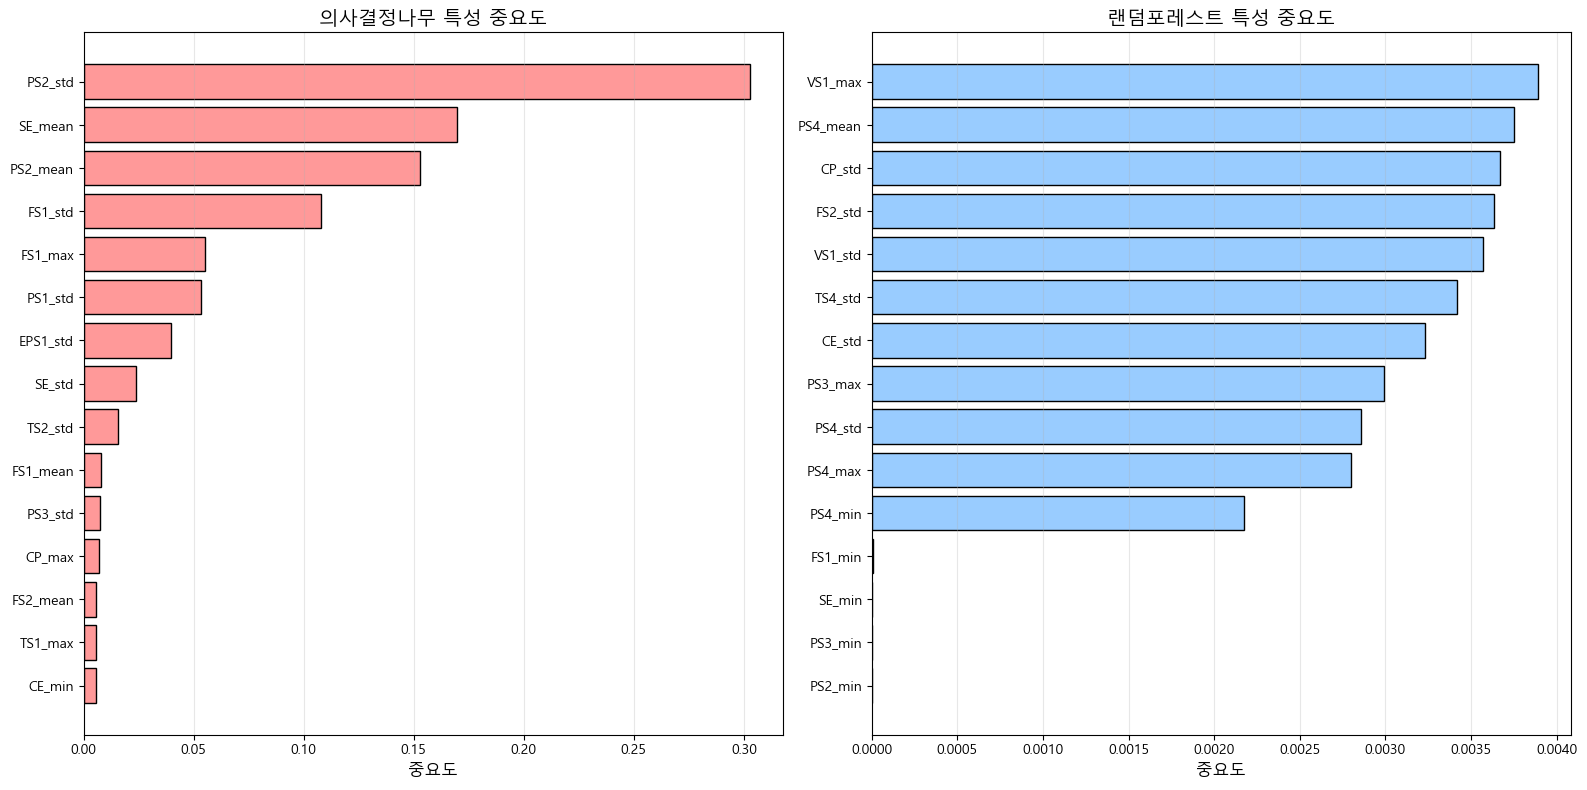

In [17]:
# 특성 중요도 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
top_n = 15

# 의사결정나무
ax1 = axes[0]
dt_sorted_idx = np.argsort(dt_importances)[::-1][:top_n]
ax1.barh(range(top_n), dt_importances[dt_sorted_idx][::-1], color='#FF9999', edgecolor='black')
ax1.set_yticks(range(top_n))
ax1.set_yticklabels([X.columns[i] for i in dt_sorted_idx[::-1]])
ax1.set_xlabel('중요도', fontsize=12)
ax1.set_title(f'의사결정나무 특성 중요도', fontsize=14)
ax1.grid(True, axis='x', alpha=0.3)

# 랜덤포레스트
ax2 = axes[1]
ax2.barh(range(top_n), rf_importances[rf_sorted_idx][::-1][:top_n], color='#99CCFF', edgecolor='black')
ax2.set_yticks(range(top_n))
ax2.set_yticklabels([X.columns[i] for i in rf_sorted_idx[::-1][:top_n]])
ax2.set_xlabel('중요도', fontsize=12)
ax2.set_title(f'랜덤포레스트 특성 중요도', fontsize=14)
ax2.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## 3.8 예측 시연

In [18]:
# 테스트 샘플 예측 시연
np.random.seed(123)
sample_idx = np.random.choice(len(X_test), 5, replace=False)
sample_X = X_test.iloc[sample_idx]
sample_y = y_test[sample_idx]

predictions = rf.predict(sample_X)
probabilities = rf.predict_proba(sample_X)

print("=" * 70)
print("새로운 데이터 예측")
print("=" * 70)
print(f"{'샘플':>4} | {'실제':>10} | {'예측':>10} | {'정확':>4} | {'최대확률':>10}")
print("-" * 70)

for i in range(len(sample_X)):
    actual = sample_y[i]
    pred = predictions[i]
    correct = "O" if actual == pred else "X"
    max_prob = max(probabilities[i]) * 100
    print(f"{i+1:>4} | {actual:>8}% | {pred:>8}% | {correct:>4} | {max_prob:>9.1f}%")

새로운 데이터 예측
  샘플 |         실제 |         예측 |   정확 |       최대확률
----------------------------------------------------------------------
   1 |      100% |      100% |    O |      92.6%
   2 |      100% |      100% |    O |     100.0%
   3 |       80% |       80% |    O |      82.6%
   4 |      100% |      100% |    O |      99.1%
   5 |      100% |      100% |    O |      95.2%


# Part 4: [별첨] 대용량 합성 데이터 성능 비교

본 섹션에서는 이전 차시에서 활용한 **대용량 합성 데이터(30~50만 샘플)**를 활용하여 랜덤포레스트와 의사결정트리의 성능을 다각도로 비교함. 실제 제조 현장에서 발생하는 대용량 데이터 처리 시 고려해야 할 **속도, 메모리, 확장성** 등을 분석함.

## 4.1 반도체 웨이퍼 공정 합성 데이터 생성

In [19]:
def create_semiconductor_wafer_data(n_samples=150000, random_state=42):
    """
    반도체 웨이퍼 제조 공정 데이터 생성
    
    특징:
    - 클래스 경계가 겹치는 영역 존재 (100% 정확도 불가능)
    - 측정 노이즈 포함
    - 비선형 상호작용
    - 클래스 불균형 (양품 > 경결함 > 중결함)
    - 일부 특성은 타겟과 무관 (노이즈 특성)
    """
    np.random.seed(random_state)
    print(f"반도체 웨이퍼 공정 데이터 생성 중... (n={n_samples:,})")
    
    # 온도 센서 (5개 챔버)
    temp_base = np.random.normal(350, 15, n_samples)
    temp_chamber_1 = temp_base + np.random.normal(0, 5, n_samples)
    temp_chamber_2 = temp_base + np.random.normal(5, 8, n_samples)
    temp_chamber_3 = temp_base + np.random.normal(-3, 6, n_samples)
    temp_chamber_4 = temp_base + np.random.normal(2, 7, n_samples)
    temp_chamber_5 = temp_base + np.random.normal(-2, 5, n_samples)
    
    # 압력 센서 (5개)
    pressure_1 = np.random.normal(5.0, 0.8, n_samples)
    pressure_2 = np.random.normal(4.5, 0.6, n_samples)
    pressure_3 = np.random.normal(5.2, 0.9, n_samples)
    pressure_4 = np.random.normal(4.8, 0.7, n_samples)
    pressure_5 = np.random.normal(5.1, 0.8, n_samples)
    
    # 가스 유량 (5개)
    gas_flow_1 = np.random.normal(100, 15, n_samples)
    gas_flow_2 = np.random.normal(150, 20, n_samples)
    gas_flow_3 = np.random.normal(80, 12, n_samples)
    gas_flow_4 = np.random.normal(120, 18, n_samples)
    gas_flow_5 = np.random.normal(90, 14, n_samples)
    
    # RF 파워
    rf_power_fwd = np.random.normal(800, 50, n_samples)
    rf_power_ref = rf_power_fwd * np.random.uniform(0.02, 0.08, n_samples)
    rf_power_ratio = rf_power_ref / rf_power_fwd
    
    # 공정 시간
    process_time = np.random.normal(120, 10, n_samples)
    stabilization_time = np.random.normal(30, 5, n_samples)
    
    # 박막 두께
    thickness_center = np.random.normal(100, 8, n_samples)
    thickness_edge = thickness_center * np.random.uniform(0.92, 1.08, n_samples)
    thickness_uniformity = np.abs(thickness_center - thickness_edge) / thickness_center * 100
    
    # 노이즈 특성 (타겟과 무관)
    noise_sensor_1 = np.random.normal(0, 1, n_samples)
    noise_sensor_2 = np.random.normal(50, 10, n_samples)
    noise_sensor_3 = np.random.uniform(0, 100, n_samples)
    noise_sensor_4 = np.random.exponential(5, n_samples)
    noise_sensor_5 = np.random.normal(200, 30, n_samples)
    
    # 상호작용 특성
    temp_pressure_interaction = (temp_chamber_1 - 350) * (pressure_1 - 5.0)
    power_time_interaction = rf_power_fwd * process_time / 10000
    
    # 품질 점수 계산
    quality_score = (
        -0.3 * np.abs(temp_chamber_1 - 350) / 15
        -0.2 * np.abs(temp_chamber_2 - 355) / 10
        -0.25 * np.abs(pressure_1 - 5.0) / 0.5
        -0.15 * np.abs(pressure_3 - 5.2) / 0.5
        -2.0 * rf_power_ratio
        -0.4 * thickness_uniformity
        +0.1 * (gas_flow_1 > 95).astype(float) * (gas_flow_2 > 145).astype(float)
        -0.1 * np.abs(process_time - 120) / 10
        -0.3 * np.abs(temp_pressure_interaction) / 10
        + np.random.normal(0, 0.8, n_samples)
    )
    
    # 클래스 할당
    quality_class = np.zeros(n_samples, dtype=int)
    quality_class[quality_score > 0] = 0
    quality_class[(quality_score <= 0) & (quality_score > -1.5)] = 1
    quality_class[quality_score <= -1.5] = 2
    
    # 경계 노이즈 추가
    boundary_noise = np.random.uniform(0, 1, n_samples)
    near_boundary_1 = (quality_score > -0.3) & (quality_score < 0.3)
    flip_1 = near_boundary_1 & (boundary_noise < 0.25)
    quality_class[flip_1 & (quality_class == 0)] = 1
    quality_class[flip_1 & (quality_class == 1)] = 0
    
    near_boundary_2 = (quality_score > -1.8) & (quality_score < -1.2)
    flip_2 = near_boundary_2 & (boundary_noise < 0.20)
    quality_class[flip_2 & (quality_class == 1)] = 2
    quality_class[flip_2 & (quality_class == 2)] = 1
    
    # 무작위 라벨 노이즈
    random_flip = np.random.uniform(0, 1, n_samples) < 0.03
    quality_class[random_flip] = np.random.randint(0, 3, random_flip.sum())
    
    # DataFrame 구성
    df = pd.DataFrame({
        'temp_chamber_1': temp_chamber_1, 'temp_chamber_2': temp_chamber_2,
        'temp_chamber_3': temp_chamber_3, 'temp_chamber_4': temp_chamber_4,
        'temp_chamber_5': temp_chamber_5,
        'pressure_1': pressure_1, 'pressure_2': pressure_2, 'pressure_3': pressure_3,
        'pressure_4': pressure_4, 'pressure_5': pressure_5,
        'gas_flow_1': gas_flow_1, 'gas_flow_2': gas_flow_2, 'gas_flow_3': gas_flow_3,
        'gas_flow_4': gas_flow_4, 'gas_flow_5': gas_flow_5,
        'rf_power_fwd': rf_power_fwd, 'rf_power_ref': rf_power_ref,
        'rf_power_ratio': rf_power_ratio,
        'process_time': process_time, 'stabilization_time': stabilization_time,
        'thickness_center': thickness_center, 'thickness_edge': thickness_edge,
        'thickness_uniformity': thickness_uniformity,
        'temp_pressure_interaction': temp_pressure_interaction,
        'power_time_interaction': power_time_interaction,
        'sensor_aux_1': noise_sensor_1, 'sensor_aux_2': noise_sensor_2,
        'sensor_aux_3': noise_sensor_3, 'sensor_aux_4': noise_sensor_4,
        'sensor_aux_5': noise_sensor_5,
        'temp_mean': (temp_chamber_1+temp_chamber_2+temp_chamber_3+temp_chamber_4+temp_chamber_5)/5,
        'temp_std': np.std([temp_chamber_1,temp_chamber_2,temp_chamber_3,temp_chamber_4,temp_chamber_5], axis=0),
        'pressure_mean': (pressure_1+pressure_2+pressure_3+pressure_4+pressure_5)/5,
        'gas_flow_total': gas_flow_1+gas_flow_2+gas_flow_3+gas_flow_4+gas_flow_5,
        'quality_class': quality_class
    })
    
    # 셔플 및 레이블 매핑
    df = df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    df['quality_label'] = df['quality_class'].map({0:'Pass', 1:'Minor_Defect', 2:'Major_Defect'})
    
    print(f"데이터 생성 완료: {len(df):,}개 샘플, {len(df.columns)-2}개 특성")
    return df

In [20]:
# 대용량 데이터 생성 (40만개)
df_large = create_semiconductor_wafer_data(n_samples=400000, random_state=42)

# 클래스 분포
print("\n[클래스 분포]")
print(df_large['quality_label'].value_counts())

반도체 웨이퍼 공정 데이터 생성 중... (n=400,000)
데이터 생성 완료: 400,000개 샘플, 34개 특성

[클래스 분포]
quality_label
Major_Defect    332581
Minor_Defect     58464
Pass              8955
Name: count, dtype: int64


In [21]:
# 특성/타겟 분리 및 분할
feature_cols = [c for c in df_large.columns if c not in ['quality_class', 'quality_label']]
X_large = df_large[feature_cols]
y_large = df_large['quality_class'].values

X_train_lg, X_test_lg, y_train_lg, y_test_lg = train_test_split(
    X_large, y_large, test_size=0.2, random_state=42, stratify=y_large
)

print(f"학습 데이터: {len(X_train_lg):,}개")
print(f"테스트 데이터: {len(X_test_lg):,}개")

학습 데이터: 320,000개
테스트 데이터: 80,000개


## 4.2 성능 측정 유틸리티

In [22]:
import tracemalloc

def measure_performance(model, X_train, y_train, X_test, y_test, model_name):
    """모델 학습/예측 시간 및 메모리 측정"""
    results = {'model': model_name}
    
    # 메모리 측정 시작
    tracemalloc.start()
    
    # 학습 시간
    start = time.time()
    model.fit(X_train, y_train)
    results['train_time'] = time.time() - start
    
    # 메모리
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    results['memory_mb'] = peak / 1024 / 1024
    
    # 예측 시간
    start = time.time()
    y_pred = model.predict(X_test)
    results['pred_time'] = time.time() - start
    
    # 정확도
    results['train_acc'] = model.score(X_train, y_train)
    results['test_acc'] = accuracy_score(y_test, y_pred)
    results['f1'] = f1_score(y_test, y_pred, average='weighted')
    
    # 모델 정보
    if hasattr(model, 'estimators_'):
        results['n_trees'] = len(model.estimators_)
        results['total_nodes'] = sum([t.tree_.node_count for t in model.estimators_])
    else:
        results['n_trees'] = 1
        results['total_nodes'] = model.tree_.node_count
    
    return results

## 4.3 기본 성능 비교

In [23]:
print("=" * 85)
print("대용량 데이터 성능 비교 (40만 샘플)")
print("=" * 85)

models_lg = {
    '의사결정나무 (depth=None)': DecisionTreeClassifier(random_state=42),
    '의사결정나무 (depth=15)': DecisionTreeClassifier(max_depth=15, random_state=42),
    '랜덤포레스트 (n=50)': RandomForestClassifier(n_estimators=50, max_depth=15, random_state=42, n_jobs=-1),
    '랜덤포레스트 (n=100)': RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    '랜덤포레스트 (n=200)': RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
}

results_lg = []
for name, model in models_lg.items():
    print(f"\n{name} 학습 중...")
    res = measure_performance(model, X_train_lg, y_train_lg, X_test_lg, y_test_lg, name)
    results_lg.append(res)
    print(f"  학습: {res['train_time']:.2f}s, 예측: {res['pred_time']:.3f}s, "
          f"메모리: {res['memory_mb']:.0f}MB, 정확도: {res['test_acc']:.4f}")

results_df_lg = pd.DataFrame(results_lg)
print("\n" + "=" * 85)
print(results_df_lg.to_string(index=False))

대용량 데이터 성능 비교 (40만 샘플)

의사결정나무 (depth=None) 학습 중...
  학습: 31.53s, 예측: 0.027s, 메모리: 59MB, 정확도: 0.7811

의사결정나무 (depth=15) 학습 중...
  학습: 15.81s, 예측: 0.012s, 메모리: 59MB, 정확도: 0.8358

랜덤포레스트 (n=50) 학습 중...
  학습: 7.24s, 예측: 0.056s, 메모리: 657MB, 정확도: 0.8515

랜덤포레스트 (n=100) 학습 중...
  학습: 12.91s, 예측: 0.079s, 메모리: 897MB, 정확도: 0.8512

랜덤포레스트 (n=200) 학습 중...
  학습: 25.08s, 예측: 0.131s, 메모리: 1382MB, 정확도: 0.8511

              model  train_time   memory_mb  pred_time  train_acc  test_acc       f1  n_trees  total_nodes
의사결정나무 (depth=None)   31.534193   59.048525   0.027128   1.000000  0.781050 0.784992        1        63063
  의사결정나무 (depth=15)   15.812311   59.046664   0.012033   0.875753  0.835825 0.823957        1         7525
      랜덤포레스트 (n=50)    7.240758  657.220545   0.056276   0.874175  0.851500 0.819254       50       346312
     랜덤포레스트 (n=100)   12.912050  897.422360   0.079337   0.873006  0.851187 0.818438      100       687304
     랜덤포레스트 (n=200)   25.083558 1381.841345   0.131203   0.874184 

## 4.4 데이터 크기별 확장성 분석

In [24]:
# 데이터 크기별 확장성
data_sizes = [50000, 100000, 200000, 320000]
dt_scale = {'size':[], 'time':[], 'acc':[], 'memory':[]}
rf_scale = {'size':[], 'time':[], 'acc':[], 'memory':[]}

print("데이터 크기별 확장성 실험...")
for size in data_sizes:
    X_sub = X_train_lg.iloc[:size]
    y_sub = y_train_lg[:size]
    
    # 의사결정나무
    dt_s = DecisionTreeClassifier(max_depth=15, random_state=42)
    tracemalloc.start()
    start = time.time()
    dt_s.fit(X_sub, y_sub)
    dt_time = time.time() - start
    _, dt_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    
    dt_scale['size'].append(size)
    dt_scale['time'].append(dt_time)
    dt_scale['acc'].append(dt_s.score(X_test_lg, y_test_lg))
    dt_scale['memory'].append(dt_mem/1024/1024)
    
    # 랜덤포레스트
    rf_s = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    tracemalloc.start()
    start = time.time()
    rf_s.fit(X_sub, y_sub)
    rf_time = time.time() - start
    _, rf_mem = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    
    rf_scale['size'].append(size)
    rf_scale['time'].append(rf_time)
    rf_scale['acc'].append(rf_s.score(X_test_lg, y_test_lg))
    rf_scale['memory'].append(rf_mem/1024/1024)
    
    print(f"  {size:>7,}: DT={dt_time:.1f}s/{dt_scale['acc'][-1]:.3f}, RF={rf_time:.1f}s/{rf_scale['acc'][-1]:.3f}")

데이터 크기별 확장성 실험...
   50,000: DT=2.1s/0.817, RF=2.1s/0.850
  100,000: DT=4.5s/0.825, RF=3.7s/0.851
  200,000: DT=9.7s/0.834, RF=7.6s/0.851
  320,000: DT=16.1s/0.836, RF=13.1s/0.851


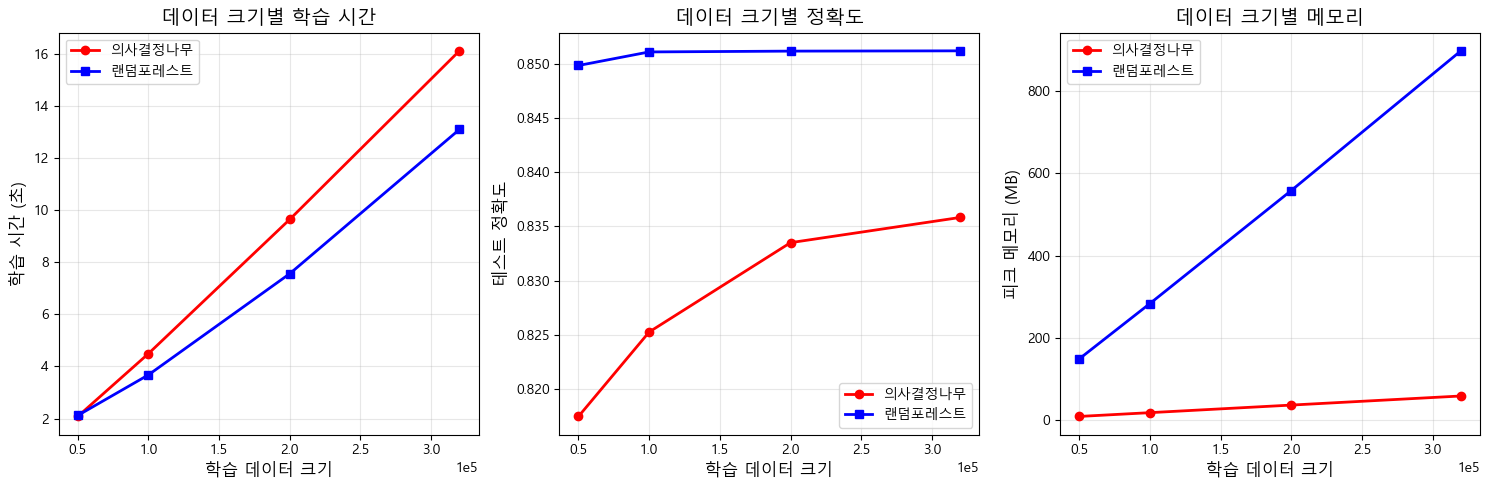

In [25]:
# 확장성 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 학습 시간
ax1 = axes[0]
ax1.plot(dt_scale['size'], dt_scale['time'], 'r-o', label='의사결정나무', linewidth=2)
ax1.plot(rf_scale['size'], rf_scale['time'], 'b-s', label='랜덤포레스트', linewidth=2)
ax1.set_xlabel('학습 데이터 크기', fontsize=12)
ax1.set_ylabel('학습 시간 (초)', fontsize=12)
ax1.set_title('데이터 크기별 학습 시간', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

# 정확도
ax2 = axes[1]
ax2.plot(dt_scale['size'], dt_scale['acc'], 'r-o', label='의사결정나무', linewidth=2)
ax2.plot(rf_scale['size'], rf_scale['acc'], 'b-s', label='랜덤포레스트', linewidth=2)
ax2.set_xlabel('학습 데이터 크기', fontsize=12)
ax2.set_ylabel('테스트 정확도', fontsize=12)
ax2.set_title('데이터 크기별 정확도', fontsize=14)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

# 메모리
ax3 = axes[2]
ax3.plot(dt_scale['size'], dt_scale['memory'], 'r-o', label='의사결정나무', linewidth=2)
ax3.plot(rf_scale['size'], rf_scale['memory'], 'b-s', label='랜덤포레스트', linewidth=2)
ax3.set_xlabel('학습 데이터 크기', fontsize=12)
ax3.set_ylabel('피크 메모리 (MB)', fontsize=12)
ax3.set_title('데이터 크기별 메모리', fontsize=14)
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

plt.tight_layout()
plt.show()

## 4.5 예측 속도 상세 분석

In [26]:
# 배치 크기별 예측 속도
dt_final_lg = DecisionTreeClassifier(max_depth=15, random_state=42)
rf_final_lg = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)

dt_final_lg.fit(X_train_lg, y_train_lg)
rf_final_lg.fit(X_train_lg, y_train_lg)

batch_sizes = [1, 10, 100, 1000, 10000, 50000, 80000]
dt_pred_times = []
rf_pred_times = []

print("배치 크기별 예측 시간 (ms)")
print("-" * 60)
print(f"{'배치크기':>10} | {'의사결정나무':>15} | {'랜덤포레스트':>15} | {'속도비':>8}")
print("-" * 60)

for bs in batch_sizes:
    X_batch = X_test_lg.iloc[:bs]
    
    dt_times = []
    rf_times = []
    for _ in range(5):
        start = time.time()
        _ = dt_final_lg.predict(X_batch)
        dt_times.append(time.time() - start)
        
        start = time.time()
        _ = rf_final_lg.predict(X_batch)
        rf_times.append(time.time() - start)
    
    dt_avg = np.mean(dt_times) * 1000
    rf_avg = np.mean(rf_times) * 1000
    ratio = rf_avg / dt_avg if dt_avg > 0 else 0
    
    dt_pred_times.append(dt_avg)
    rf_pred_times.append(rf_avg)
    
    print(f"{bs:>10,} | {dt_avg:>13.3f}ms | {rf_avg:>13.3f}ms | {ratio:>7.1f}x")

배치 크기별 예측 시간 (ms)
------------------------------------------------------------
      배치크기 |          의사결정나무 |          랜덤포레스트 |      속도비
------------------------------------------------------------
         1 |         1.335ms |        28.249ms |    21.2x
        10 |         1.045ms |        31.600ms |    30.3x
       100 |         1.207ms |        30.476ms |    25.3x
     1,000 |         1.004ms |        29.444ms |    29.3x
    10,000 |         2.676ms |        40.158ms |    15.0x
    50,000 |        10.248ms |        65.760ms |     6.4x
    80,000 |        13.714ms |        76.703ms |     5.6x


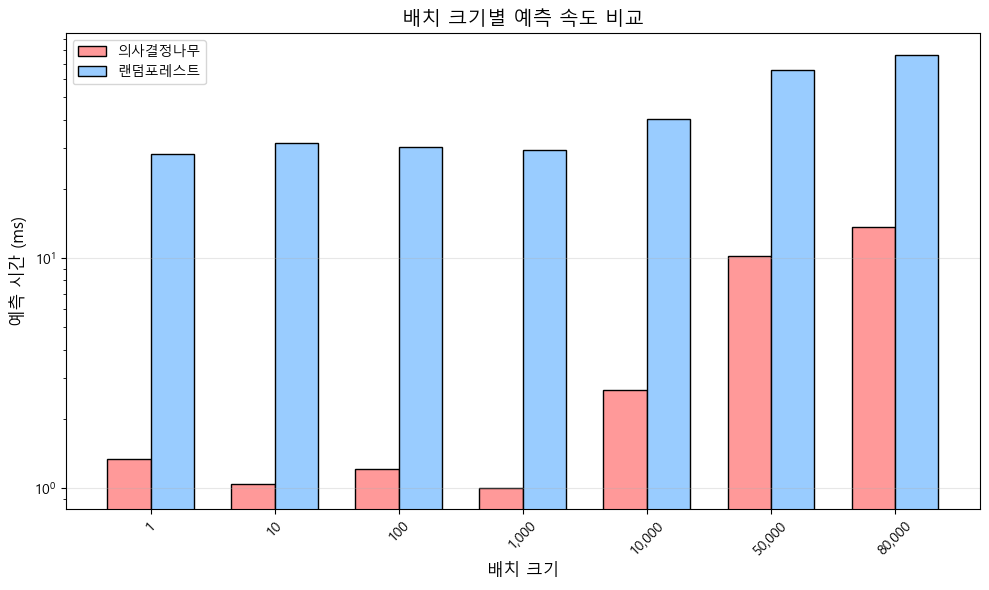

In [27]:
# 예측 속도 시각화
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(batch_sizes))
width = 0.35

ax.bar(x - width/2, dt_pred_times, width, label='의사결정나무', color='#FF9999', edgecolor='black')
ax.bar(x + width/2, rf_pred_times, width, label='랜덤포레스트', color='#99CCFF', edgecolor='black')

ax.set_xlabel('배치 크기', fontsize=12)
ax.set_ylabel('예측 시간 (ms)', fontsize=12)
ax.set_title('배치 크기별 예측 속도 비교', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([f'{bs:,}' for bs in batch_sizes], rotation=45)
ax.legend()
ax.set_yscale('log')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 4.6 대용량 데이터 안정성 비교

In [28]:
# 대용량 데이터 안정성 (10회 반복)
n_repeats_lg = 10
dt_lg_scores = []
rf_lg_scores = []

print(f"대용량 데이터 안정성 비교 ({n_repeats_lg}회)...")
for i in range(n_repeats_lg):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_large, y_large, test_size=0.2, random_state=i, stratify=y_large
    )
    # 속도를 위해 일부만 사용
    X_tr_sub = X_tr.iloc[:100000]
    y_tr_sub = y_tr[:100000]
    
    dt_t = DecisionTreeClassifier(max_depth=15, random_state=i)
    dt_t.fit(X_tr_sub, y_tr_sub)
    dt_lg_scores.append(dt_t.score(X_te, y_te))
    
    rf_t = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=i, n_jobs=-1)
    rf_t.fit(X_tr_sub, y_tr_sub)
    rf_lg_scores.append(rf_t.score(X_te, y_te))

print(f"\n[의사결정나무] 평균: {np.mean(dt_lg_scores):.4f}, 표준편차: {np.std(dt_lg_scores):.4f}")
print(f"[랜덤포레스트] 평균: {np.mean(rf_lg_scores):.4f}, 표준편차: {np.std(rf_lg_scores):.4f}")
if np.std(rf_lg_scores) > 0:
    print(f"\n--> 랜덤포레스트가 {np.std(dt_lg_scores)/np.std(rf_lg_scores):.1f}배 더 안정적")

대용량 데이터 안정성 비교 (10회)...

[의사결정나무] 평균: 0.8271, 표준편차: 0.0012
[랜덤포레스트] 평균: 0.8508, 표준편차: 0.0006

--> 랜덤포레스트가 2.0배 더 안정적


## 4.7 종합 비교 결과

In [29]:
print("\n" + "=" * 80)
print("[종합 비교 결과표]")
print("=" * 80)

comparison = {
    '지표': ['학습 시간', '예측 시간 (8만건)', '메모리 사용량', '테스트 정확도', 
            'F1 점수', '안정성 (표준편차)'],
    '의사결정나무': [
        f"{dt_scale['time'][-1]:.1f}초",
        f"{dt_pred_times[-1]:.1f}ms",
        f"{dt_scale['memory'][-1]:.0f}MB",
        f"{dt_scale['acc'][-1]:.4f}",
        f"{f1_score(y_test_lg, dt_final_lg.predict(X_test_lg), average='weighted'):.4f}",
        f"{np.std(dt_lg_scores):.4f}"
    ],
    '랜덤포레스트': [
        f"{rf_scale['time'][-1]:.1f}초",
        f"{rf_pred_times[-1]:.1f}ms",
        f"{rf_scale['memory'][-1]:.0f}MB",
        f"{rf_scale['acc'][-1]:.4f}",
        f"{f1_score(y_test_lg, rf_final_lg.predict(X_test_lg), average='weighted'):.4f}",
        f"{np.std(rf_lg_scores):.4f}"
    ],
    '승자': ['의사결정나무', '의사결정나무', '의사결정나무', '랜덤포레스트', '랜덤포레스트', '랜덤포레스트']
}

print(pd.DataFrame(comparison).to_string(index=False))


[종합 비교 결과표]
         지표 의사결정나무 랜덤포레스트     승자
      학습 시간  16.1초  13.1초 의사결정나무
예측 시간 (8만건) 13.7ms 76.7ms 의사결정나무
    메모리 사용량   59MB  897MB 의사결정나무
    테스트 정확도 0.8358 0.8512 랜덤포레스트
      F1 점수 0.8240 0.8184 랜덤포레스트
 안정성 (표준편차) 0.0012 0.0006 랜덤포레스트


# 핵심 정리

## 수학 공식 정리

| 공식 | 설명 |
|------|------|
| $\hat{y} = \text{mode}\{f_1(x), \ldots, f_B(x)\}$ | 분류: 다수결 투표 |
| $\hat{y} = \frac{1}{B}\sum_{b=1}^{B}f_b(x)$ | 회귀: 평균 |
| $P = (1-\frac{1}{n})^n \approx e^{-1} \approx 0.368$ | 부트스트랩 제외 확률 |
| $Var = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$ | 상관된 앙상블 분산 |

## sklearn 사용법 요약

```python
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,    # 트리 개수
    max_depth=None,      # 트리 깊이
    max_features='sqrt', # 분할 시 특성 수
    random_state=42,     # 재현성
    n_jobs=-1,           # 병렬 처리
    oob_score=True       # OOB 점수
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
importances = model.feature_importances_
```

## 상황별 권장 모델

| 상황 | 권장 | 이유 |
|------|------|------|
| 높은 정확도 필요 | 랜덤포레스트 | 우수한 일반화 |
| 실시간 예측 | 의사결정나무 | 빠른 예측 |
| 메모리 제한 | 의사결정나무 | 낮은 메모리 |
| 안정적 성능 | 랜덤포레스트 | 낮은 분산 |